In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv('insurance_claims.csv')
df1.head()

,patient_id,policy_id,insurance_plan,coverage_amount,hospital_visits,doctor_visits,prescription_count,emergency_visits,claim_count,annual_medical_expenses,policy_tenure_years,preventive_checkup,charges
0,106367,POL745021,Premium,1000000,1,1,3,0,1,4892.98,2.0,Yes,17611.75
1,101878,POL220895,Basic,1000000,2,7,2,0,1,4727.17,12.4,Yes,23498.10
2,104168,POL950550,Standard,1000000,5,2,4,1,0,6105.70,0.7,Yes,21154.36
3,108542,POL481161,Standard,750000,2,3,5,0,2,3243.25,9.8,Yes,17800.14
4,102601,POL789984,Standard,250000,2,4,5,0,1,2663.40,9.4,Yes,42721.63


In [3]:
df1.shape

(14080, 13)

In [4]:
df1.duplicated().sum()

np.int64(80)

In [5]:
df1.drop_duplicates(inplace=True)

In [6]:
df1.duplicated().sum()

np.int64(0)

In [7]:
df1.isnull().sum()

patient_id                   0
policy_id                    0
insurance_plan             140
coverage_amount              0
hospital_visits              0
doctor_visits                0
prescription_count           0
emergency_visits             0
claim_count                  0
annual_medical_expenses    140
policy_tenure_years          0
preventive_checkup         140
charges                      0
dtype: int64

In [8]:
df1.dtypes

patient_id                   int64
policy_id                   object
insurance_plan              object
coverage_amount              int64
hospital_visits              int64
doctor_visits                int64
prescription_count           int64
emergency_visits             int64
claim_count                  int64
annual_medical_expenses    float64
policy_tenure_years        float64
preventive_checkup          object
charges                    float64
dtype: object

In [9]:
ca = ['insurance_plan','preventive_checkup']
for i in ca:
    df1[i] = df1[i].fillna(df1[i].mode()[0])

In [10]:
df1['annual_medical_expenses'] = df1['annual_medical_expenses'].fillna(df1['annual_medical_expenses'].mean())

In [11]:
df1.isnull().sum()

patient_id                 0
policy_id                  0
insurance_plan             0
coverage_amount            0
hospital_visits            0
doctor_visits              0
prescription_count         0
emergency_visits           0
claim_count                0
annual_medical_expenses    0
policy_tenure_years        0
preventive_checkup         0
charges                    0
dtype: int64

In [12]:
df2 = pd.read_csv('patient_details.csv')
df2.head()

,patient_id,age,sex,bmi,children,smoker,region,medical_history,occupation,income_level,exercise_level,family_history
0,100001,19,Male,26.67,5,No,East,NaN,Student,Middle,NaN,No
1,100002,24,Female,21.15,3,Yes,North,Hypertension,Retired,High,Moderate,No
2,100003,44,Male,34.01,2,No,South,Asthma,Business,High,Low,No
3,100004,74,Female,32.15,1,No,East,NaN,Self-Employed,Middle,Moderate,No
4,100005,31,Male,29.55,2,No,East,NaN,Retired,High,Moderate,No


In [13]:
df2.shape

(10060, 12)

In [14]:
df2.duplicated().sum()

np.int64(60)

In [15]:
df2.drop_duplicates(inplace=True)

In [16]:
df2.duplicated().sum()

np.int64(0)

In [17]:
df2.isnull().sum()

patient_id            0
age                   0
sex                   0
bmi                 100
children              0
smoker                0
region                0
medical_history    5013
occupation            0
income_level          0
exercise_level      100
family_history        0
dtype: int64

In [18]:
df2.dtypes

patient_id           int64
age                  int64
sex                 object
bmi                float64
children             int64
smoker              object
region              object
medical_history     object
occupation          object
income_level        object
exercise_level      object
family_history      object
dtype: object

In [19]:
df2 = df2.drop(['medical_history'],axis=1)

In [20]:
df2['bmi'] = df2['bmi'].fillna(df2['bmi'].mean())

In [21]:
df2['exercise_level'] = df2['exercise_level'].fillna(df2['exercise_level'].mode()[0])

In [22]:
df2.isnull().sum()

patient_id        0
age               0
sex               0
bmi               0
children          0
smoker            0
region            0
occupation        0
income_level      0
exercise_level    0
family_history    0
dtype: int64

In [23]:
df = pd.merge(df1, df2, on='patient_id', how='inner')

In [24]:
df.head()

,patient_id,policy_id,insurance_plan,coverage_amount,hospital_visits,doctor_visits,prescription_count,emergency_visits,claim_count,annual_medical_expenses,...,age,sex,bmi,children,smoker,region,occupation,income_level,exercise_level,family_history
0,106367,POL745021,Premium,1000000,1,1,3,0,1,4892.98,...,32,Female,23.17,0,No,West,Retired,High,Moderate,No
1,101878,POL220895,Basic,1000000,2,7,2,0,1,4727.17,...,73,Male,17.46,0,No,East,Salaried,Middle,Moderate,Yes
2,104168,POL950550,Standard,1000000,5,2,4,1,0,6105.70,...,25,Male,32.10,2,No,North,Student,Middle,Low,Yes
3,108542,POL481161,Standard,750000,2,3,5,0,2,3243.25,...,24,Male,27.05,1,No,East,Student,Middle,Moderate,No
4,102601,POL789984,Standard,250000,2,4,5,0,1,2663.40,...,40,Male,34.14,1,Yes,North,Student,Middle,Moderate,No


In [25]:
df.shape

(14000, 23)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.isnull().sum()

patient_id                 0
policy_id                  0
insurance_plan             0
coverage_amount            0
hospital_visits            0
doctor_visits              0
prescription_count         0
emergency_visits           0
claim_count                0
annual_medical_expenses    0
policy_tenure_years        0
preventive_checkup         0
charges                    0
age                        0
sex                        0
bmi                        0
children                   0
smoker                     0
region                     0
occupation                 0
income_level               0
exercise_level             0
family_history             0
dtype: int64

In [28]:
df.dtypes

patient_id                   int64
policy_id                   object
insurance_plan              object
coverage_amount              int64
hospital_visits              int64
doctor_visits                int64
prescription_count           int64
emergency_visits             int64
claim_count                  int64
annual_medical_expenses    float64
policy_tenure_years        float64
preventive_checkup          object
charges                    float64
age                          int64
sex                         object
bmi                        float64
children                     int64
smoker                      object
region                      object
occupation                  object
income_level                object
exercise_level              object
family_history              object
dtype: object

In [29]:
Num_cols = df.dtypes[df.dtypes!='object'].index
Cat_cols = df.dtypes[df.dtypes=='object'].index
print(Num_cols)
print(Cat_cols)

Index(['patient_id', 'coverage_amount', 'hospital_visits', 'doctor_visits',
       'prescription_count', 'emergency_visits', 'claim_count',
       'annual_medical_expenses', 'policy_tenure_years', 'charges', 'age',
       'bmi', 'children'],
      dtype='object')
Index(['policy_id', 'insurance_plan', 'preventive_checkup', 'sex', 'smoker',
       'region', 'occupation', 'income_level', 'exercise_level',
       'family_history'],
      dtype='object')


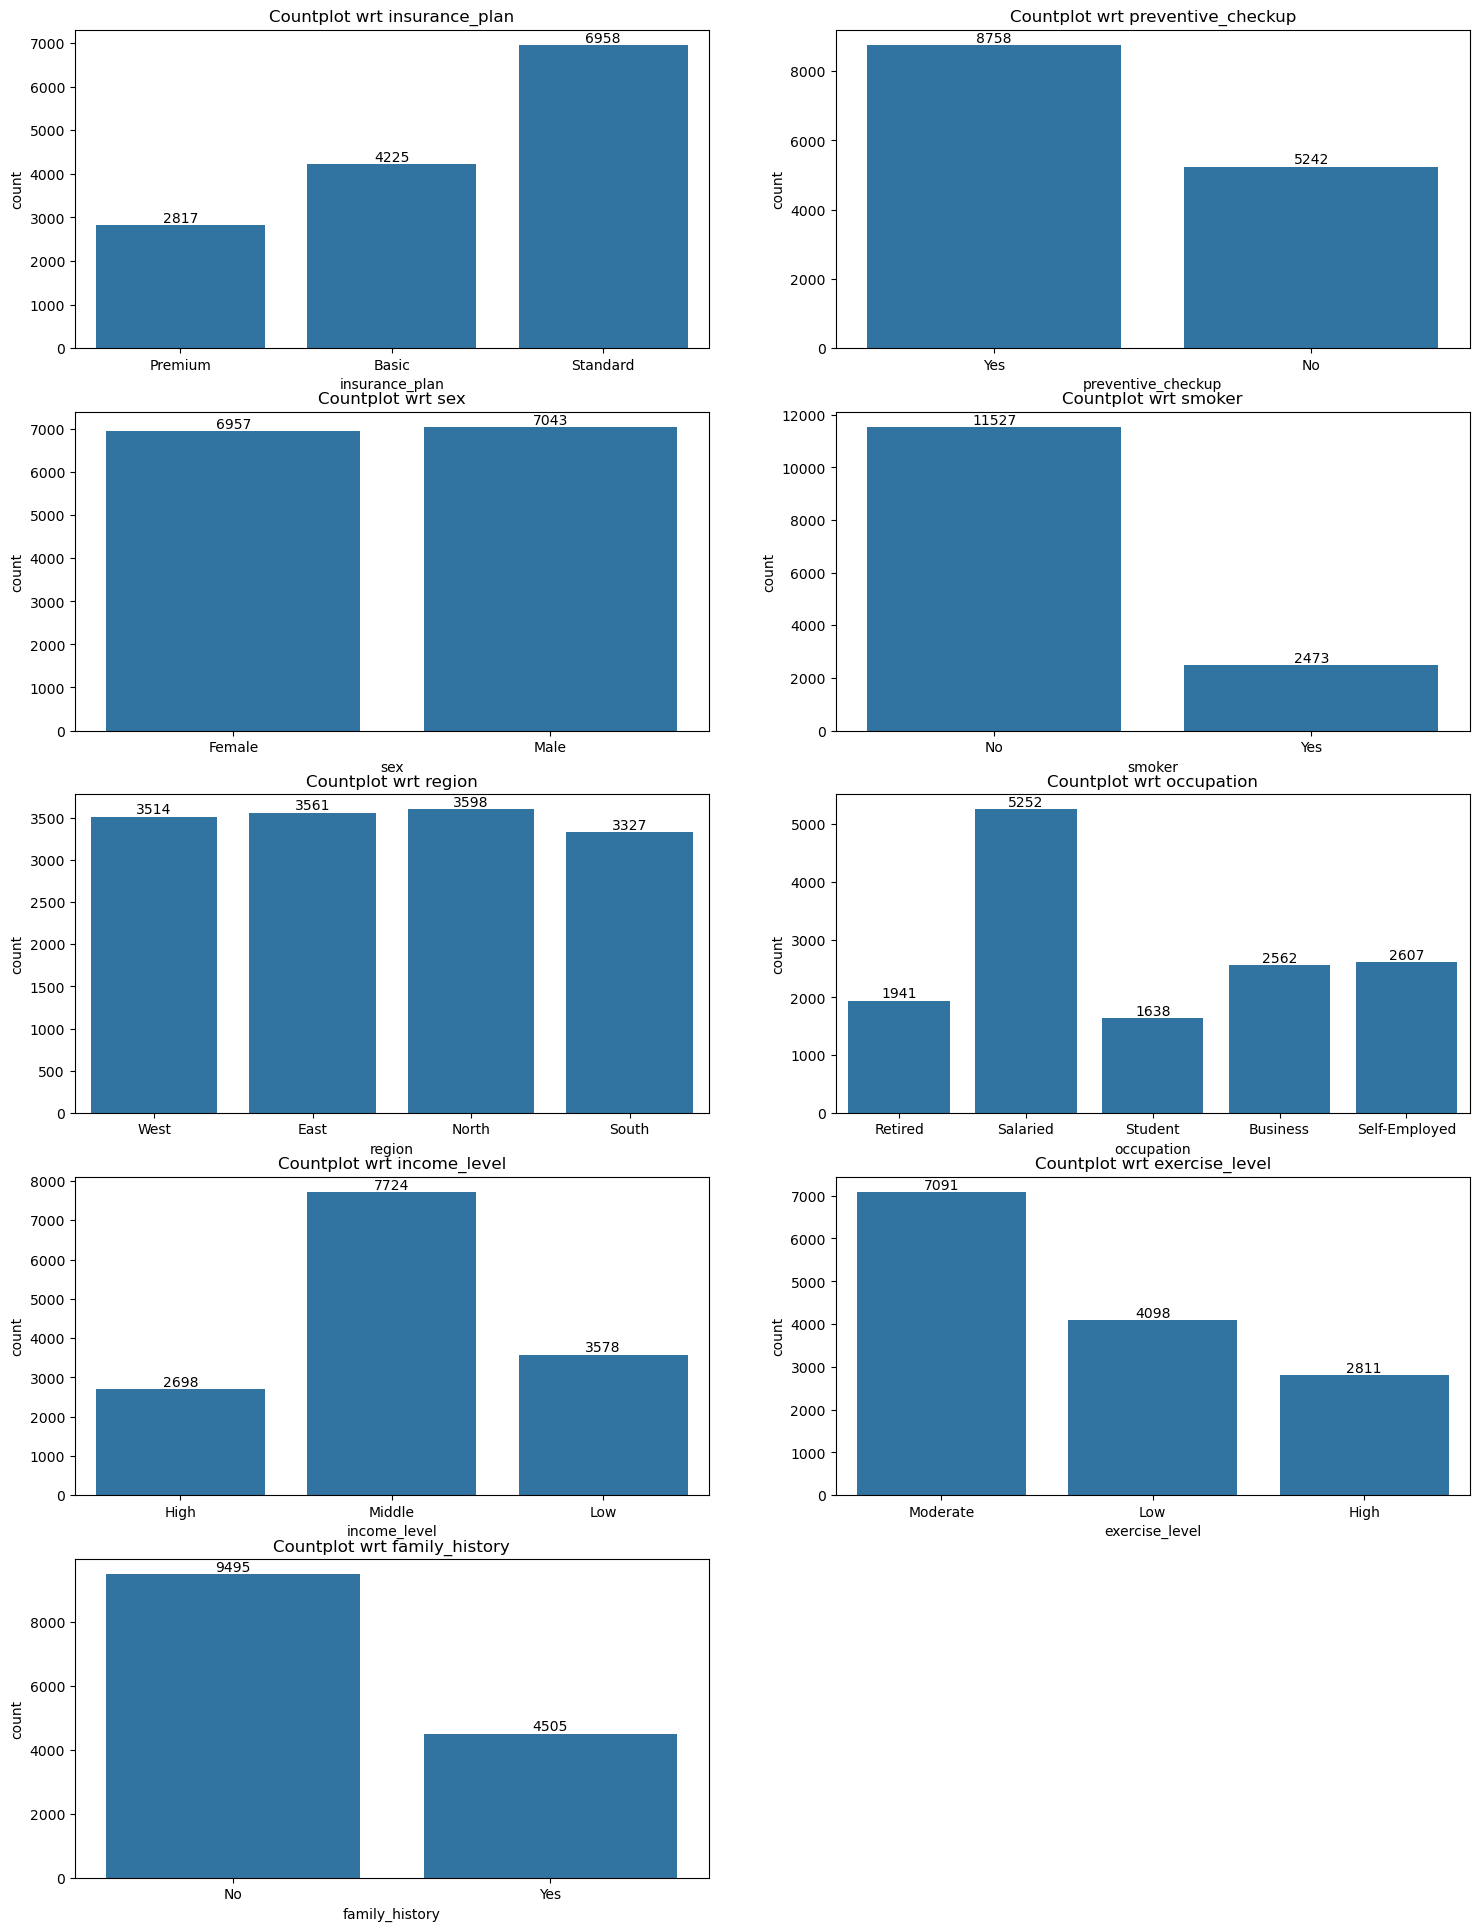

In [30]:
cols = Cat_cols[1:]
plt.figure(figsize=[18,24])
for i in range(len(cols)):
    plt.subplot(5,2,i+1)
    ax=sns.countplot(data=df,x=cols[i])
    ax.bar_label(ax.containers[0])
    plt.title(f'Countplot wrt {cols[i]}')
plt.show()

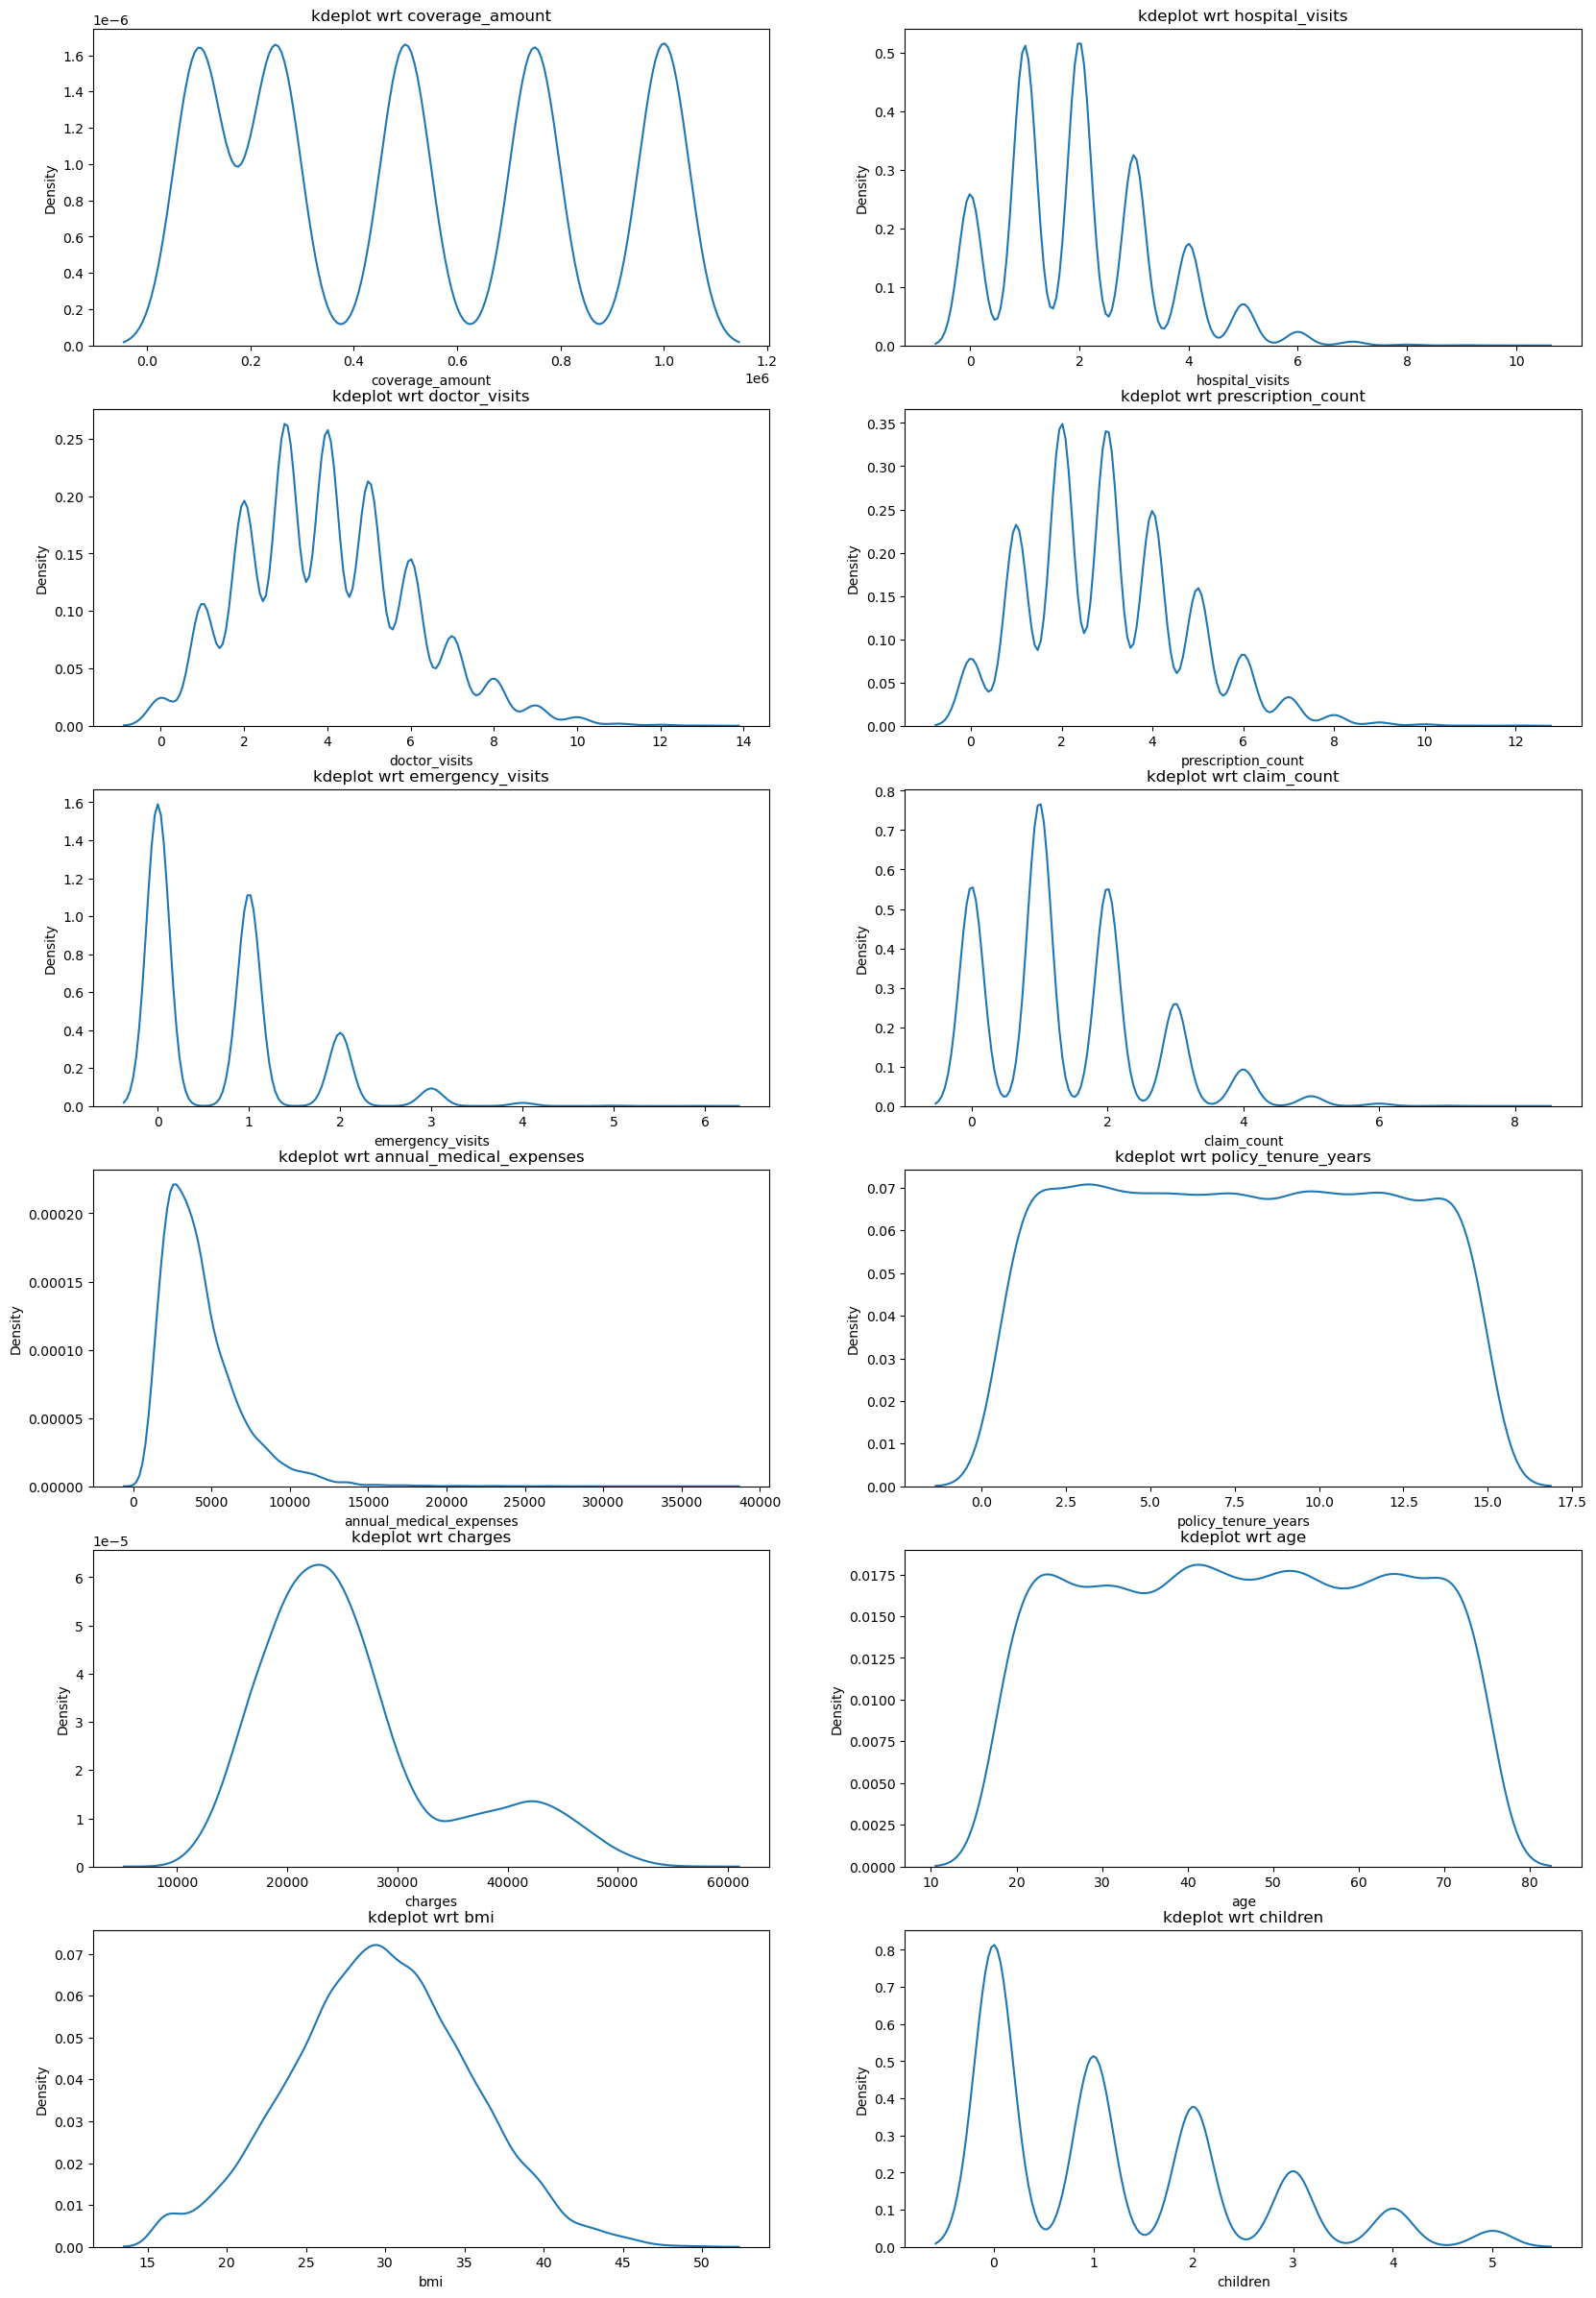

In [31]:
cols = Num_cols[1:]
plt.figure(figsize=[20,30])
for i in range(len(cols)):
    plt.subplot(6,2,i+1)
    ax=sns.kdeplot(data=df,x=cols[i])

    plt.title(f'kdeplot wrt {cols[i]}')
plt.show()

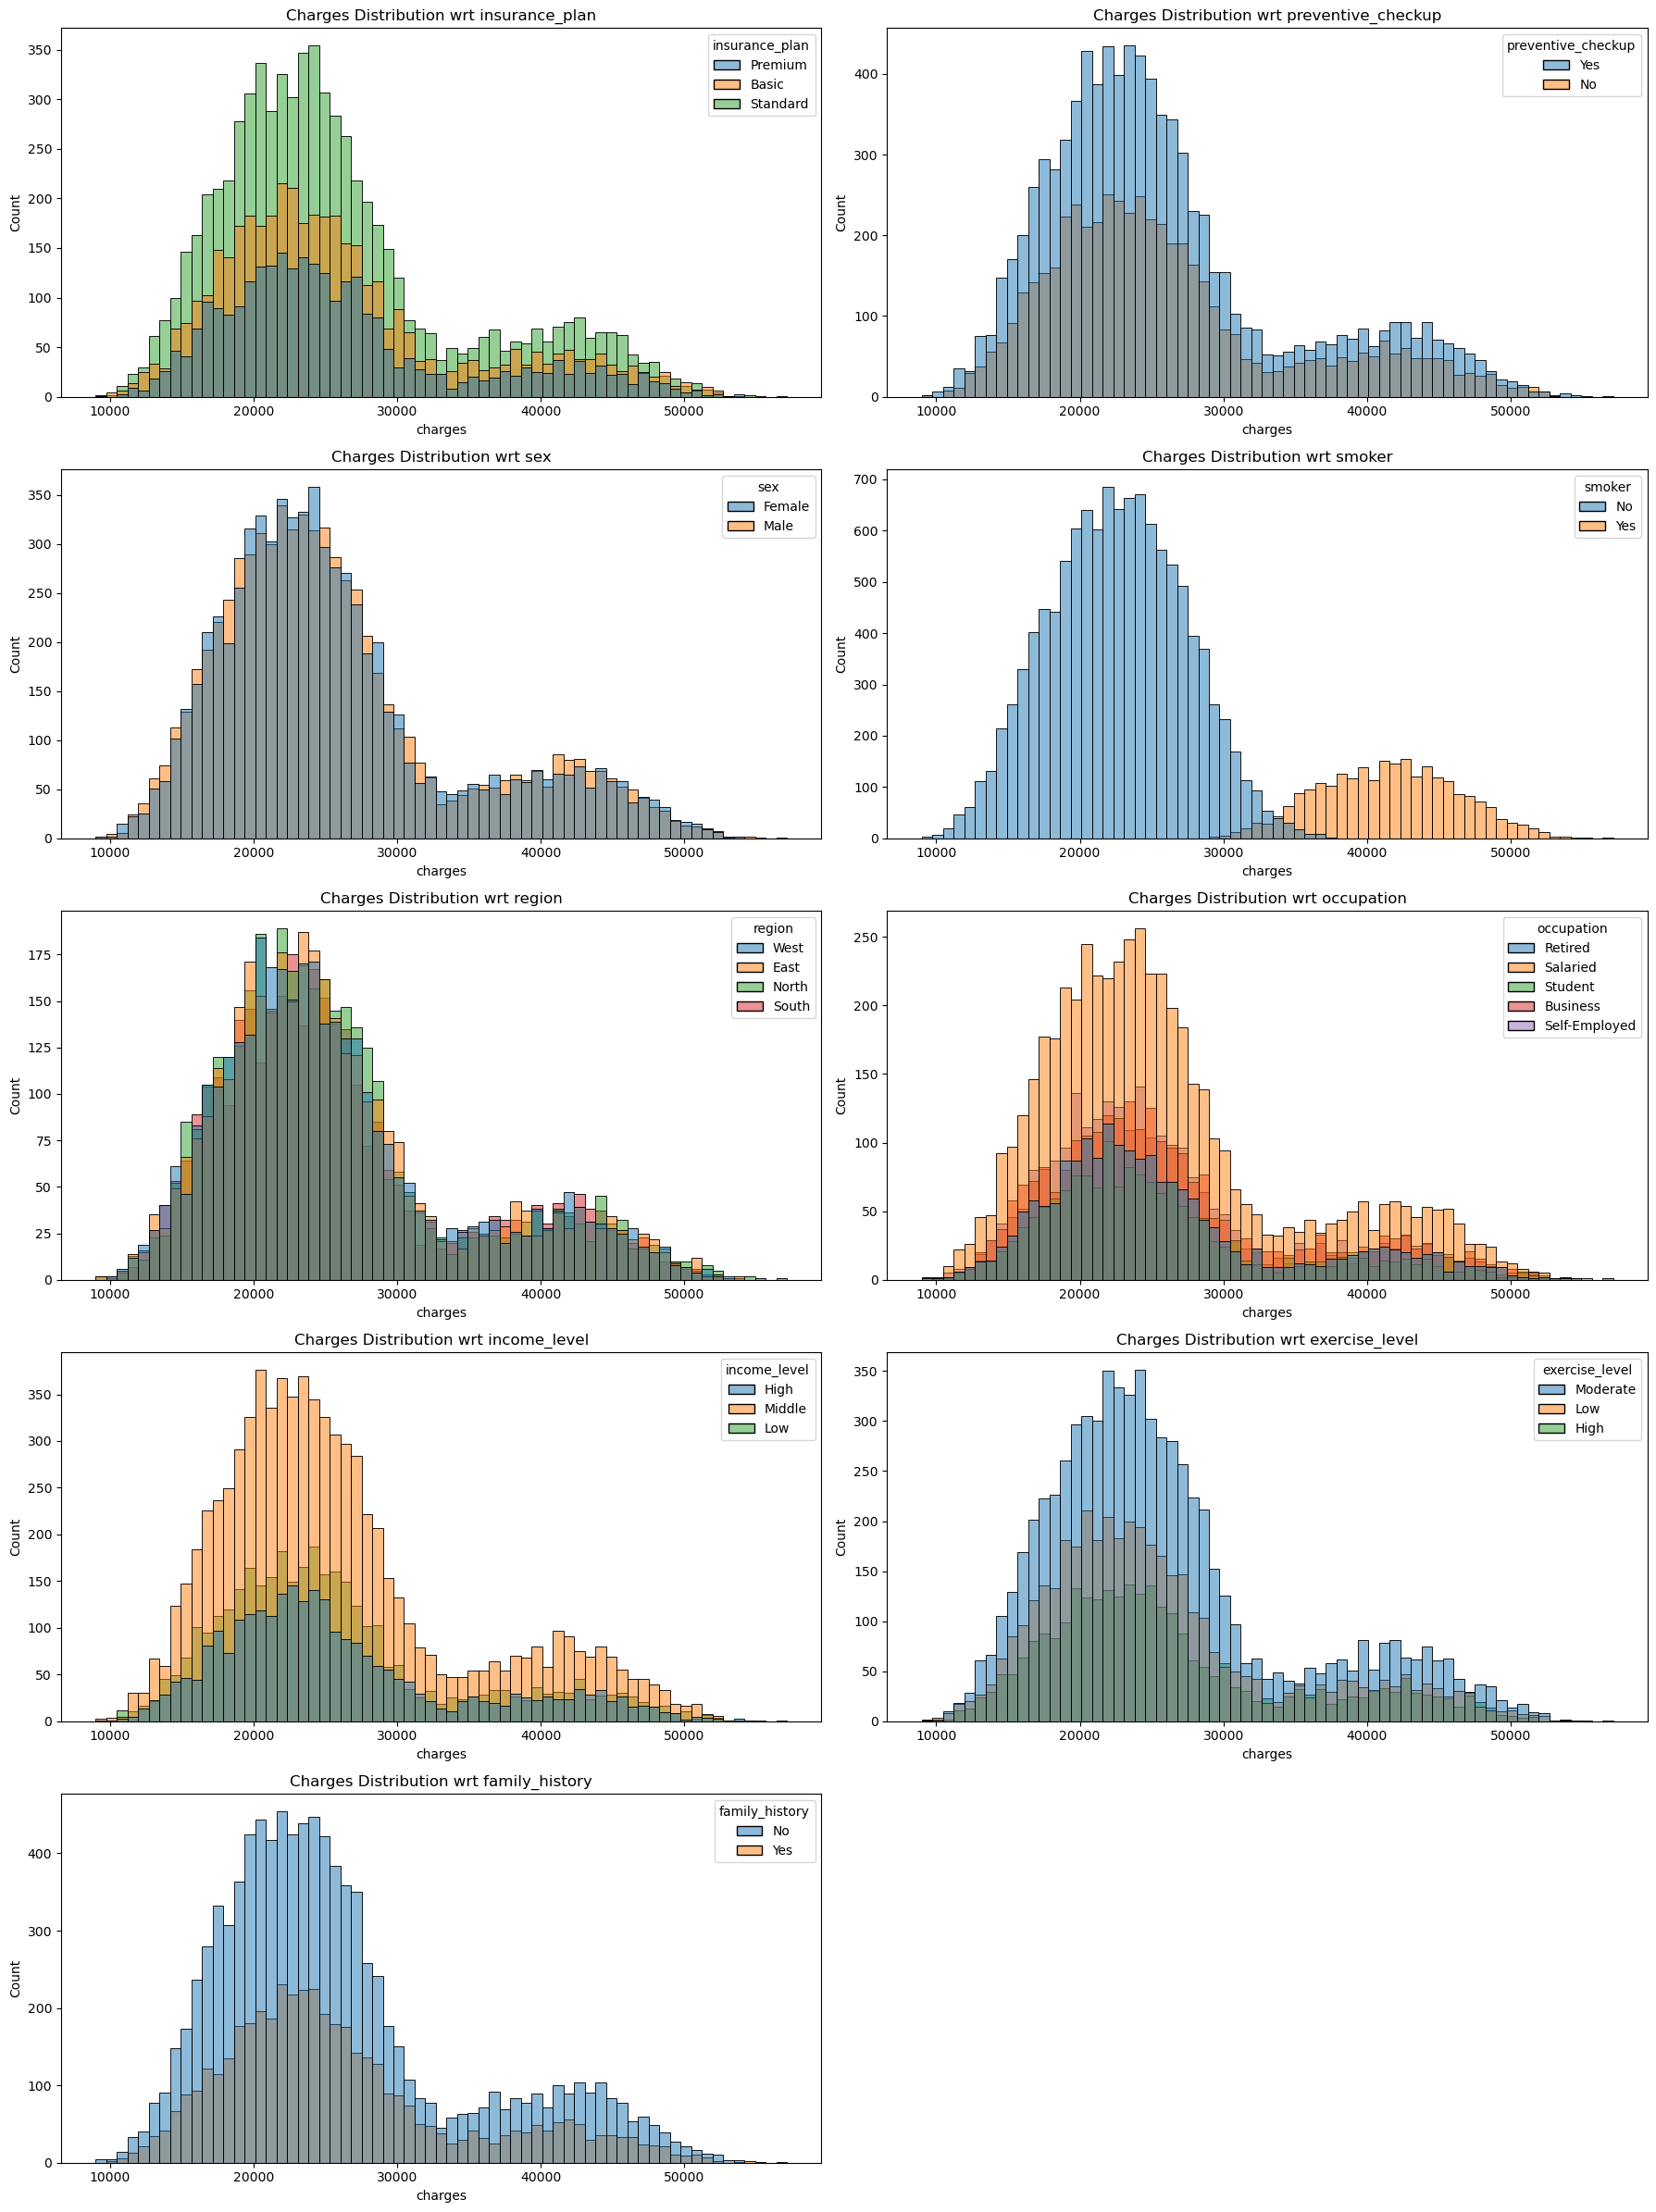

In [32]:
cols = Cat_cols[1:]

plt.figure(figsize=[18, 24])

for i in range(len(cols)):
    plt.subplot(5, 2, i+1)
    sns.histplot(data=df,x='charges',hue=cols[i],)
    plt.title(f'Charges Distribution wrt {cols[i]}')

plt.tight_layout()
plt.show()

<Axes: >

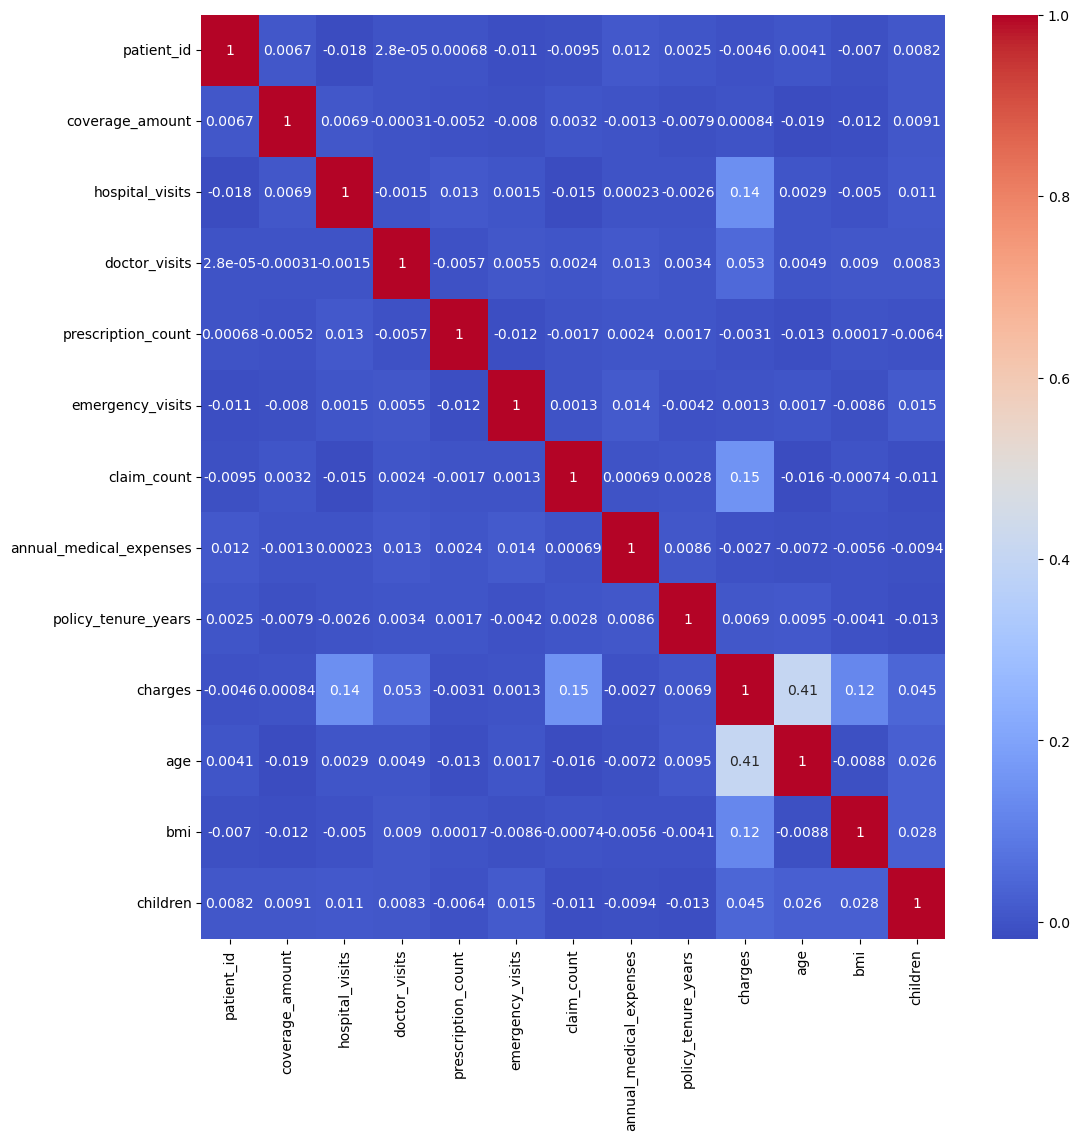

In [33]:
cols = Num_cols[:]
plt.figure(figsize=(12,12))
corr = df[cols].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')

In [34]:
w = df[Num_cols[1:]].describe(percentiles=[0.01,0.02,0.05,0.97,0.98,0.99]).T
w = w.iloc[:,3:]
w

,min,1%,2%,5%,50%,97%,98%,99%,max
coverage_amount,100000.00,100000.0000,100000.0000,100000.000,500000.000000,1000000.0000,1000000.0000,1000000.0000,1000000.00
hospital_visits,0.00,0.0000,0.0000,0.000,2.000000,5.0000,5.0000,6.0000,10.00
doctor_visits,0.00,0.0000,1.0000,1.000,4.000000,8.0000,9.0000,9.0000,13.00
prescription_count,0.00,0.0000,0.0000,0.000,3.000000,7.0000,7.0000,8.0000,12.00
emergency_visits,0.00,0.0000,0.0000,0.000,1.000000,3.0000,3.0000,3.0000,6.00
claim_count,0.00,0.0000,0.0000,0.000,1.000000,4.0000,4.0000,5.0000,8.00
annual_medical_expenses,503.80,1022.7041,1200.1502,1479.304,3677.150000,10212.6250,11170.3878,12478.7910,37556.77
policy_tenure_years,0.50,0.7000,0.8000,1.200,7.700000,14.6000,14.7000,14.9000,15.00
charges,8992.82,12739.2930,13614.7964,15240.903,23968.525000,46160.3871,47411.9288,48962.2751,57139.42
age,18.00,18.0000,19.0000,20.000,47.000000,74.0000,74.0000,75.0000,75.00


In [35]:
left_sk = ['annual_medical_expenses','policy_tenure_years','charges']
right_sk = ['hospital_visits','doctor_visits','prescription_count','emergency_visits','claim_count','annual_medical_expenses','policy_tenure_years','charges','bmi']

In [36]:
for i in left_sk:
    lower = df[i].quantile(0.01)
    df[i] = np.where(df[i]<lower,lower,df[i])

In [37]:
for i in right_sk:
    upper = df[i].quantile(0.99)
    df[i] = np.where(df[i]>upper,upper,df[i])

In [38]:
w = df[Num_cols[1:]].describe(percentiles=[0.01,0.02,0.05,0.97,0.98,0.99]).T
w = w.iloc[:,3:]
w

,min,1%,2%,5%,50%,97%,98%,99%,max
coverage_amount,100000.0000,100000.000000,100000.0000,100000.000,500000.000000,1000000.0000,1000000.0000,1000000.000000,1000000.0000
hospital_visits,0.0000,0.000000,0.0000,0.000,2.000000,5.0000,5.0000,6.000000,6.0000
doctor_visits,0.0000,0.000000,1.0000,1.000,4.000000,8.0000,9.0000,9.000000,9.0000
prescription_count,0.0000,0.000000,0.0000,0.000,3.000000,7.0000,7.0000,8.000000,8.0000
emergency_visits,0.0000,0.000000,0.0000,0.000,1.000000,3.0000,3.0000,3.000000,3.0000
claim_count,0.0000,0.000000,0.0000,0.000,1.000000,4.0000,4.0000,5.000000,5.0000
annual_medical_expenses,1022.7041,1022.729741,1200.1502,1479.304,3677.150000,10212.6250,11170.3878,12478.681110,12478.7910
policy_tenure_years,0.7000,0.700000,0.8000,1.200,7.700000,14.6000,14.7000,14.900000,14.9000
charges,12739.2930,12739.309830,13614.7964,15240.903,23968.525000,46160.3871,47411.9288,48962.180951,48962.2751
age,18.0000,18.000000,19.0000,20.000,47.000000,74.0000,74.0000,75.000000,75.0000


In [39]:
print(Cat_cols)

Index(['policy_id', 'insurance_plan', 'preventive_checkup', 'sex', 'smoker',
       'region', 'occupation', 'income_level', 'exercise_level',
       'family_history'],
      dtype='object')


In [40]:
df['occupation'].value_counts()

occupation
Salaried         5252
Self-Employed    2607
Business         2562
Retired          1941
Student          1638
Name: count, dtype: int64

In [41]:
df['preventive_checkup'] = df['preventive_checkup'].replace({'Yes':1,'No':0})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\2933432094.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['preventive_checkup'] = df['preventive_checkup'].replace({'Yes':1,'No':0})


In [42]:
df['insurance_plan'] = df['insurance_plan'].replace({'Standard':1,'Basic':0,'Premium':2})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\1973133051.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['insurance_plan'] = df['insurance_plan'].replace({'Standard':1,'Basic':0,'Premium':2})


In [43]:
df['sex'] = df['sex'].replace({'Male':1,'Female':0})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\3415952070.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'Male':1,'Female':0})


In [44]:
df['smoker'] = df['smoker'].replace({'Yes':1,'No':0})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\1934620398.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'Yes':1,'No':0})


In [45]:
df['region'] = df['region'].replace({'North':0,'East':1,'West':2,'South':3})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\3807457447.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['region'] = df['region'].replace({'North':0,'East':1,'West':2,'South':3})


In [46]:
df['income_level'] = df['income_level'].replace({'Low':0,'Middle':1,'High':2})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\94916627.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income_level'] = df['income_level'].replace({'Low':0,'Middle':1,'High':2})


In [47]:
df['exercise_level'] = df['exercise_level'].replace({'Low':0,'Moderate':1,'High':2})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\3668891913.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exercise_level'] = df['exercise_level'].replace({'Low':0,'Moderate':1,'High':2})


In [48]:
df['family_history'] = df['family_history'].replace({'Yes':1,'No':0})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_24212\3562489731.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['family_history'] = df['family_history'].replace({'Yes':1,'No':0})


In [49]:
cols_decode = ['occupation']
df_dummies = pd.get_dummies(data=df,columns=cols_decode,dtype=int,drop_first=True)
df_dummies.shape

(14000, 26)

In [50]:
x = df_dummies.drop(['charges','patient_id','policy_id'],axis=1)
y = df_dummies['charges']
print(x.shape,y.shape)

(14000, 23) (14000,)


In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(9800, 23) (9800,)
(4200, 23) (4200,)


In [52]:
from sklearn.metrics import *

In [53]:
def eval_model(x_train,x_test,y_train,y_test,model,mname):
    model.fit(x_train,y_train)
    ypred = model.predict(x_test)
    train_score = model.score(x_train,y_train)
    test_score = model.score(x_test,y_test)
    mae = mean_absolute_error(y_test,ypred)
    mse = mean_squared_error(y_test,ypred)
    rmse = np.sqrt(mse)
    eval_df = pd.DataFrame({'Train R2':train_score,'Test R2':test_score,'MAE':mae,
                             'MSE':mse,'RMSE':rmse},index=[mname])
    return ypred,eval_df

In [54]:
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [56]:
lr = LinearRegression()
ypred_lr,eval_lr = eval_model(x_train,x_test,y_train,y_test,lr,'LinReg')
eval_lr

,Train R2,Test R2,MAE,MSE,RMSE
LinReg,0.933974,0.934959,1831.849493,4.807100e+06,2192.509977


In [57]:
dt = DecisionTreeRegressor(min_samples_leaf=20,min_samples_split=20,max_depth=8)
ypred_dt,eval_dt = eval_model(x_train,x_test,y_train,y_test,dt,'Decision Tree')
eval_dt

,Train R2,Test R2,MAE,MSE,RMSE
Decision Tree,0.922369,0.908314,2122.01417,6.776355e+06,2603.143311


In [58]:
rt = RandomForestRegressor(min_samples_leaf=20,min_samples_split=20,n_estimators=80,oob_score=True,random_state=34,max_depth=8,max_samples=500,n_jobs=-1)
ypred_rt,eval_rt = eval_model(x_train,x_test,y_train,y_test,rt,'RandomForest Tree')
eval_rt

,Train R2,Test R2,MAE,MSE,RMSE
RandomForest Tree,0.902522,0.902375,2180.879662,7.215305e+06,2686.132025


In [59]:
xgb_reg = XGBRegressor(objective='reg:squarederror',eval_metric='rmse',eta=0.01,reg_lambda=0.4,gamma=0.28)

ypred_xgb_reg, eval_xgb_reg = eval_model(x_train, x_test, y_train, y_test,xgb_reg,'xgboost')

eval_xgb_reg

,Train R2,Test R2,MAE,MSE,RMSE
xgboost,0.794717,0.791983,3115.638434,1.537414e+07,3920.986485


In [60]:
Ada1 = AdaBoostRegressor(n_estimators=70)

ypred_Ada1, eval_Ada1 = eval_model(x_train, x_test, y_train, y_test,Ada1,'Adaboost')

eval_Ada1

,Train R2,Test R2,MAE,MSE,RMSE
Adaboost,0.909959,0.910013,2123.881555,6.650806e+06,2578.915661


In [61]:
all_res = pd.concat([eval_lr,eval_dt,eval_rt,eval_Ada1,eval_xgb_reg])
all_res

,Train R2,Test R2,MAE,MSE,RMSE
LinReg,0.933974,0.934959,1831.849493,4.807100e+06,2192.509977
Decision Tree,0.922369,0.908314,2122.014170,6.776355e+06,2603.143311
RandomForest Tree,0.902522,0.902375,2180.879662,7.215305e+06,2686.132025
Adaboost,0.909959,0.910013,2123.881555,6.650806e+06,2578.915661
xgboost,0.794717,0.791983,3115.638434,1.537414e+07,3920.986485


In [62]:
fimp = pd.DataFrame()
fimp['Feature'] = x_train.columns
fimp['FImp'] = rt.feature_importances_
fimp = fimp.sort_values('FImp',ascending=False)
fimp

,Feature,FImp
14,smoker,0.778917
10,age,0.183068
6,claim_count,0.016044
12,bmi,0.009816
2,hospital_visits,0.009169
3,doctor_visits,0.000709
7,annual_medical_expenses,0.000708
8,policy_tenure_years,0.000549
13,children,0.000333
15,region,0.000144


In [63]:
from sklearn.model_selection import RandomizedSearchCV

In [66]:
hparams_rf = {'n_estimators':[70,75,80,85],
              'max_depth':[5,6,7],
              'min_samples_split':[8,10,12]}

In [67]:
rf_base = RandomForestRegressor()
rs = RandomizedSearchCV(estimator = rf_base, param_distributions = hparams_rf, cv=5,
                        scoring='neg_mean_squared_error',n_iter=30)
rs.fit(x_train,y_train)

,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [5, 6, ...], 'min_samples_split': [8, 10, ...], 'n_estimators': [70, 75, ...]}"
,n_iter,30
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [68]:
print(rs.best_score_)
print(rs.best_params_)

-6005640.898334814
{'n_estimators': 80, 'min_samples_split': 12, 'max_depth': 7}


In [69]:
rf2 = RandomForestRegressor(**rs.best_params_)
ypred_rf2, eval_rf2 = eval_model(x_train,x_test,y_train,y_test,rf2,'RF2_Reg')
eval_rf2

,Train R2,Test R2,MAE,MSE,RMSE
RF2_Reg,0.928344,0.920029,1988.602527,5.910478e+06,2431.147473


In [70]:
param_grid = {'n_estimators': [100, 200, 300],'max_depth': [3, 5, 7],'learning_rate': [0.01, 0.05, 0.1],
                                'subsample': [0.7, 0.8, 1.0],'colsample_bytree': [0.7, 0.8, 1.0]}

In [71]:
xgb_reg1 = XGBRegressor()
random_search = RandomizedSearchCV(estimator=xgb_reg1,param_distributions=param_grid,n_iter=10,
                                   cv=3,scoring='neg_root_mean_squared_error',random_state=42,n_jobs=-1,verbose=1)

random_search.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [72]:
print(random_search.best_score_)
print(random_search.best_params_)

-2233.6968765847528
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [73]:
xgb2 = XGBRegressor(**random_search.best_params_)

ypred_xgb2, eval_xgb2 = eval_model(x_train,x_test,y_train,y_test,xgb2,'XGB2_Reg')

eval_xgb2

,Train R2,Test R2,MAE,MSE,RMSE
XGB2_Reg,0.937185,0.933827,1841.574549,4.890744e+06,2211.502642


In [74]:
all_res1 = pd.concat([eval_xgb2,eval_rf2])
all_res1

,Train R2,Test R2,MAE,MSE,RMSE
XGB2_Reg,0.937185,0.933827,1841.574549,4.890744e+06,2211.502642
RF2_Reg,0.928344,0.920029,1988.602527,5.910478e+06,2431.147473


In [75]:
import pickle

In [76]:
pickle.dump(xgb2,open('Insurance_price_prediction1.pkl', 'wb'))